# 📈 Time Series Analysis — Complete Practical Guide

This notebook walks through **every major concept** in time series analysis using real-world datasets:
- 🌿 **Mauna Loa CO₂** (weekly, 1958–2001) — long seasonal series
- ☀️ **Sunspot Numbers** (annual, 1700–) — cyclical natural series
- 📊 **US Macroeconomic Data** (quarterly) — multivariate economic series

Each section maps directly to the mind map:
1. Foundations → Decomposition → Stationarity → Forecasting Models → Smoothing → Evaluation → Pre-processing

In [23]:
# ── Core Imports ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.dates import YearLocator, DateFormatter

# Stats & Models
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'lines.linewidth': 1.6,
    'font.size': 11,
})
COLORS = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657', '#79c0ff']

print('✅ All imports successful')

✅ All imports successful


---
## 📦 Section 0 — Load Real-World Datasets

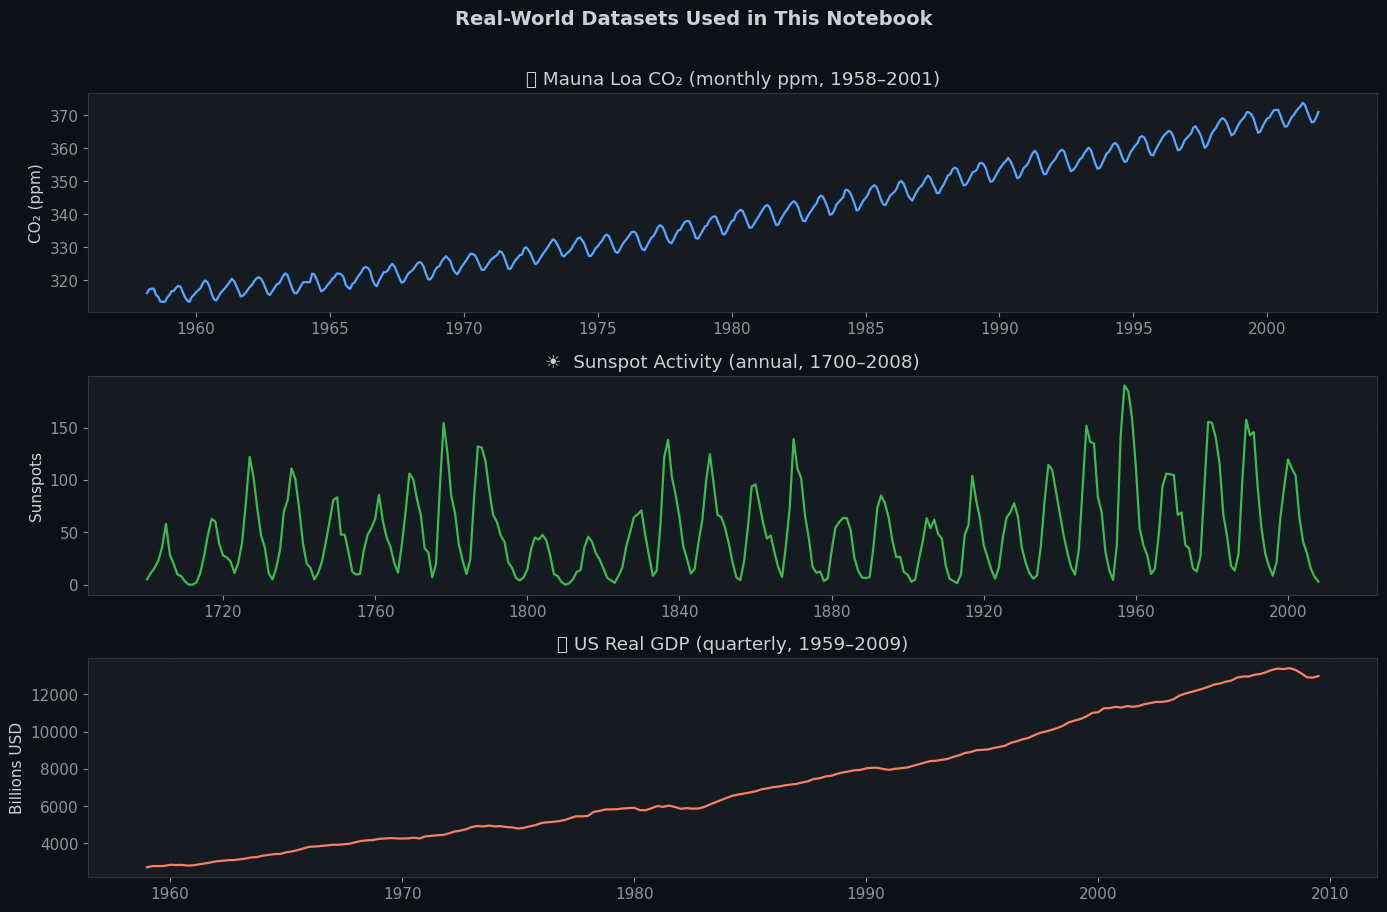

CO₂ shape: (526, 1)  |  Sunspots shape: (309, 1)  |  Macro shape: (203, 14)


In [3]:
# ── Dataset 1: Mauna Loa CO₂ (weekly) ────────────────────────────────────────
co2_raw = sm.datasets.co2.load_pandas().data
co2 = co2_raw.resample('MS').mean()          # resample to monthly
co2 = co2.ffill()                             # fill 3 missing values
co2.index = pd.DatetimeIndex(co2.index, freq='MS')

# ── Dataset 2: Sunspot Numbers (annual) ───────────────────────────────────────
sunspots = sm.datasets.sunspots.load_pandas().data
sunspots.index = pd.DatetimeIndex(
    pd.to_datetime(sunspots['YEAR'].astype(int).astype(str)), freq='AS')
sunspots = sunspots[['SUNACTIVITY']]

# ── Dataset 3: US Macroeconomic (quarterly) ───────────────────────────────────
macro = sm.datasets.macrodata.load_pandas().data
macro.index = pd.date_range('1959Q1', periods=len(macro), freq='QS')

# Quick overview
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.suptitle('Real-World Datasets Used in This Notebook', fontsize=14, fontweight='bold', y=1.01)

axes[0].plot(co2.index, co2['co2'], color=COLORS[0])
axes[0].set_title('🌿 Mauna Loa CO₂ (monthly ppm, 1958–2001)')
axes[0].set_ylabel('CO₂ (ppm)')

axes[1].plot(sunspots.index, sunspots['SUNACTIVITY'], color=COLORS[1])
axes[1].set_title('☀️  Sunspot Activity (annual, 1700–2008)')
axes[1].set_ylabel('Sunspots')

axes[2].plot(macro.index, macro['realgdp'], color=COLORS[2])
axes[2].set_title('📊 US Real GDP (quarterly, 1959–2009)')
axes[2].set_ylabel('Billions USD')

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'CO₂ shape: {co2.shape}  |  Sunspots shape: {sunspots.shape}  |  Macro shape: {macro.shape}')

---
## 🏗️ Section 1 — Foundations
### 1.1 What is a Time Series? (Definition + Characteristics)

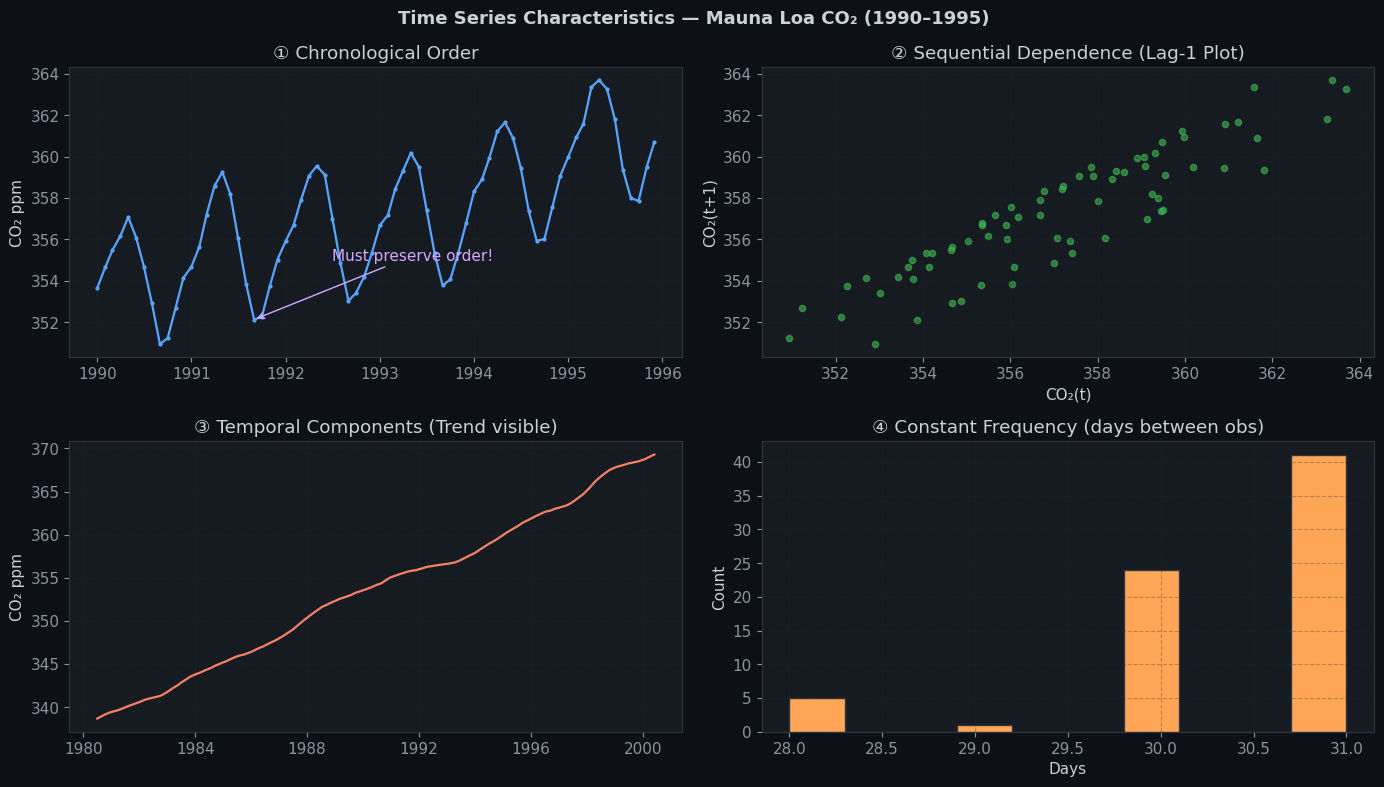

KEY INSIGHT: A time series is ordered, dependent, regular-frequency data with hidden temporal structure.


In [24]:
# Demonstrate key CHARACTERISTICS of the CO₂ series
sample = co2['1990':'1995']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Time Series Characteristics — Mauna Loa CO₂ (1990–1995)', fontsize=13, fontweight='bold')

# 1) Chronological order
axes[0,0].plot(sample.index, sample['co2'], color=COLORS[0], marker='o', markersize=2)
axes[0,0].set_title('① Chronological Order')
axes[0,0].set_ylabel('CO₂ ppm')
axes[0,0].annotate('Must preserve order!', xy=(sample.index[20], sample['co2'].iloc[20]),
                   xytext=(sample.index[30], 355), color=COLORS[3],
                   arrowprops=dict(arrowstyle='->', color=COLORS[3]))

# 2) Sequential dependence via lag plot
axes[0,1].scatter(sample['co2'].iloc[:-1].values,
                  sample['co2'].iloc[1:].values,
                  color=COLORS[1], alpha=0.6, s=20)
axes[0,1].set_title('② Sequential Dependence (Lag-1 Plot)')
axes[0,1].set_xlabel('CO₂(t)'); axes[0,1].set_ylabel('CO₂(t+1)')

# 3) Temporal components — show trend + seasonal
result = seasonal_decompose(co2['co2']['1980':'2000'], model='additive', period=12)
axes[1,0].plot(result.trend.index, result.trend, color=COLORS[2], label='Trend')
axes[1,0].set_title('③ Temporal Components (Trend visible)')
axes[1,0].set_ylabel('CO₂ ppm')

# 4) Constant frequency
diffs = pd.Series(sample.index).diff().dropna().dt.days
axes[1,1].hist(diffs, bins=10, color=COLORS[4], edgecolor='#30363d')
axes[1,1].set_title('④ Constant Frequency (days between obs)')
axes[1,1].set_xlabel('Days'); axes[1,1].set_ylabel('Count')

for ax in axes.flat: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('KEY INSIGHT: A time series is ordered, dependent, regular-frequency data with hidden temporal structure.')

### 1.2 Goals: Understand Past + Forecast Future

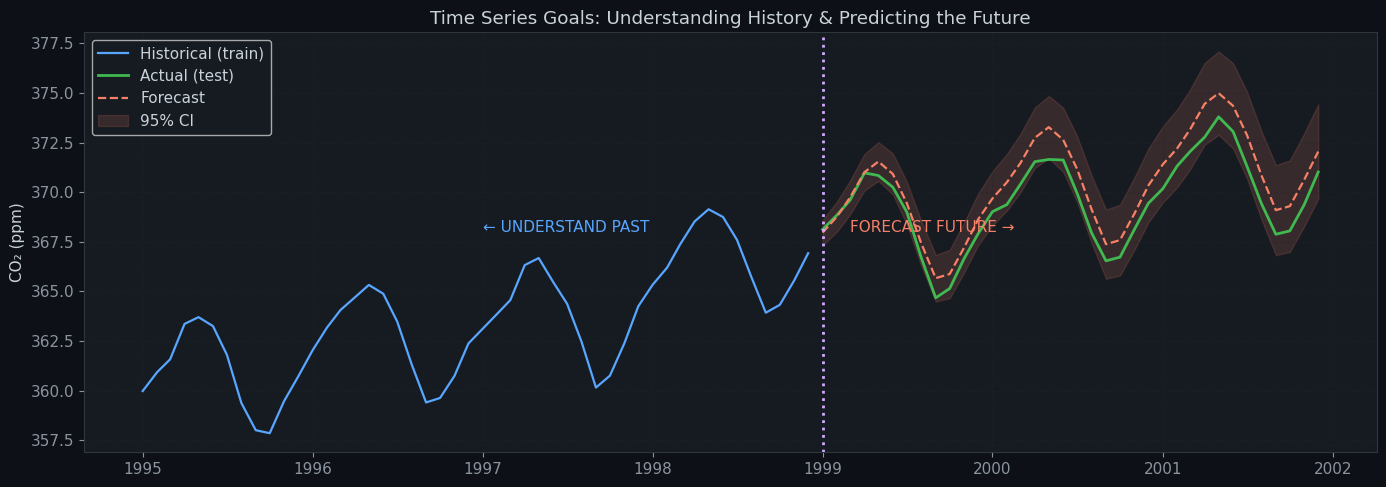

Forecast MAE on held-out 3 years: 0.933 ppm  (impressively low for ~3yr ahead!)


In [5]:
# Show "understand past" vs "forecast future" split visually
train = co2['co2'][:'1998']
test  = co2['co2']['1999':'2001']

model = ARIMA(train, order=(2,1,2), seasonal_order=(1,1,1,12))
fitted = model.fit()
forecast = fitted.get_forecast(steps=len(test))
fc_mean = forecast.predicted_mean
fc_ci   = forecast.conf_int()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-48:].index, train[-48:], color=COLORS[0], label='Historical (train)')
ax.plot(test.index, test, color=COLORS[1], label='Actual (test)', linewidth=2)
ax.plot(fc_mean.index, fc_mean, color=COLORS[2], linestyle='--', label='Forecast')
ax.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                color=COLORS[2], alpha=0.15, label='95% CI')
ax.axvline(x=pd.Timestamp('1999-01-01'), color=COLORS[3], linestyle=':', linewidth=2)
ax.text(pd.Timestamp('1997-01-01'), 368, '← UNDERSTAND PAST', color=COLORS[0], fontsize=11)
ax.text(pd.Timestamp('1999-03-01'), 368, 'FORECAST FUTURE →', color=COLORS[2], fontsize=11)
ax.set_title('Time Series Goals: Understanding History & Predicting the Future')
ax.set_ylabel('CO₂ (ppm)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

mae = mean_absolute_error(test, fc_mean)
print(f'Forecast MAE on held-out 3 years: {mae:.3f} ppm  (impressively low for ~3yr ahead!)')

---
## 🔍 Section 2 — Decomposition
### 2.1 Components: Trend, Seasonality, Cyclic, Residual

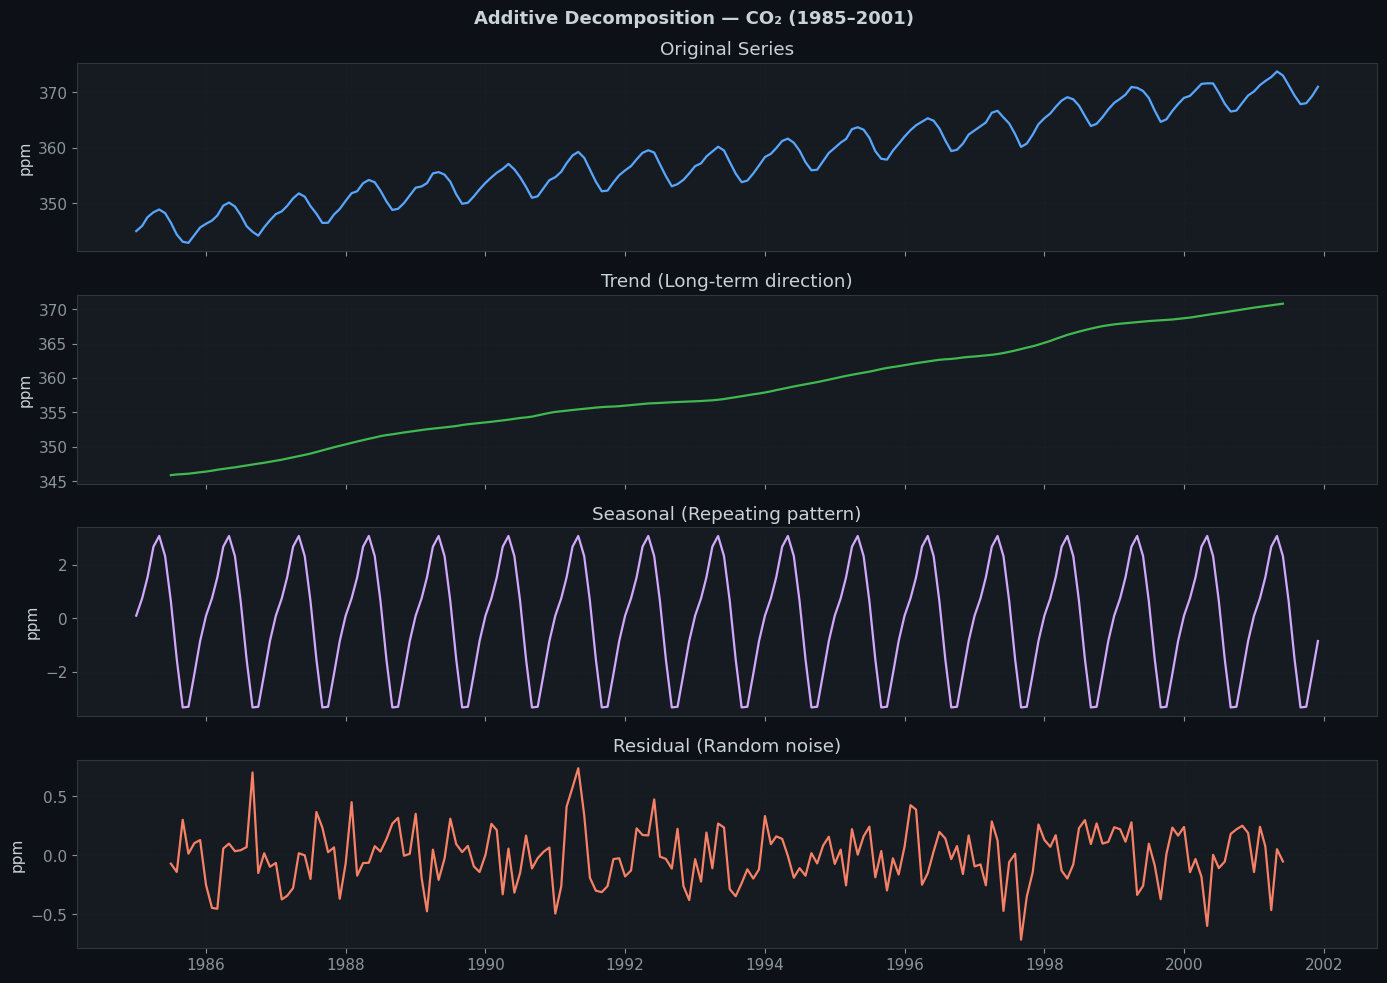

FORMULA:  Observed = Trend + Seasonal + Residual  (Additive)
Trend range: 345.9 → 370.8 ppm  (CO₂ rising!)
Seasonal amplitude: ±3.3 ppm  (plant photosynthesis cycle)


In [6]:
# Classical decomposition on CO₂
decomp = seasonal_decompose(co2['co2']['1985':'2001'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Additive Decomposition — CO₂ (1985–2001)', fontsize=13, fontweight='bold')

components = [
    (decomp.observed,  'Original Series',             COLORS[0]),
    (decomp.trend,     'Trend (Long-term direction)',  COLORS[1]),
    (decomp.seasonal,  'Seasonal (Repeating pattern)', COLORS[3]),
    (decomp.resid,     'Residual (Random noise)',      COLORS[2]),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data, color=color)
    ax.set_title(title); ax.grid(True, alpha=0.3)
    ax.set_ylabel('ppm')

plt.tight_layout(); plt.show()

print('FORMULA:  Observed = Trend + Seasonal + Residual  (Additive)')
print(f'Trend range: {decomp.trend.min():.1f} → {decomp.trend.max():.1f} ppm  (CO₂ rising!)')
print(f'Seasonal amplitude: ±{decomp.seasonal.abs().max():.1f} ppm  (plant photosynthesis cycle)')

### 2.2 Models: Additive vs Multiplicative

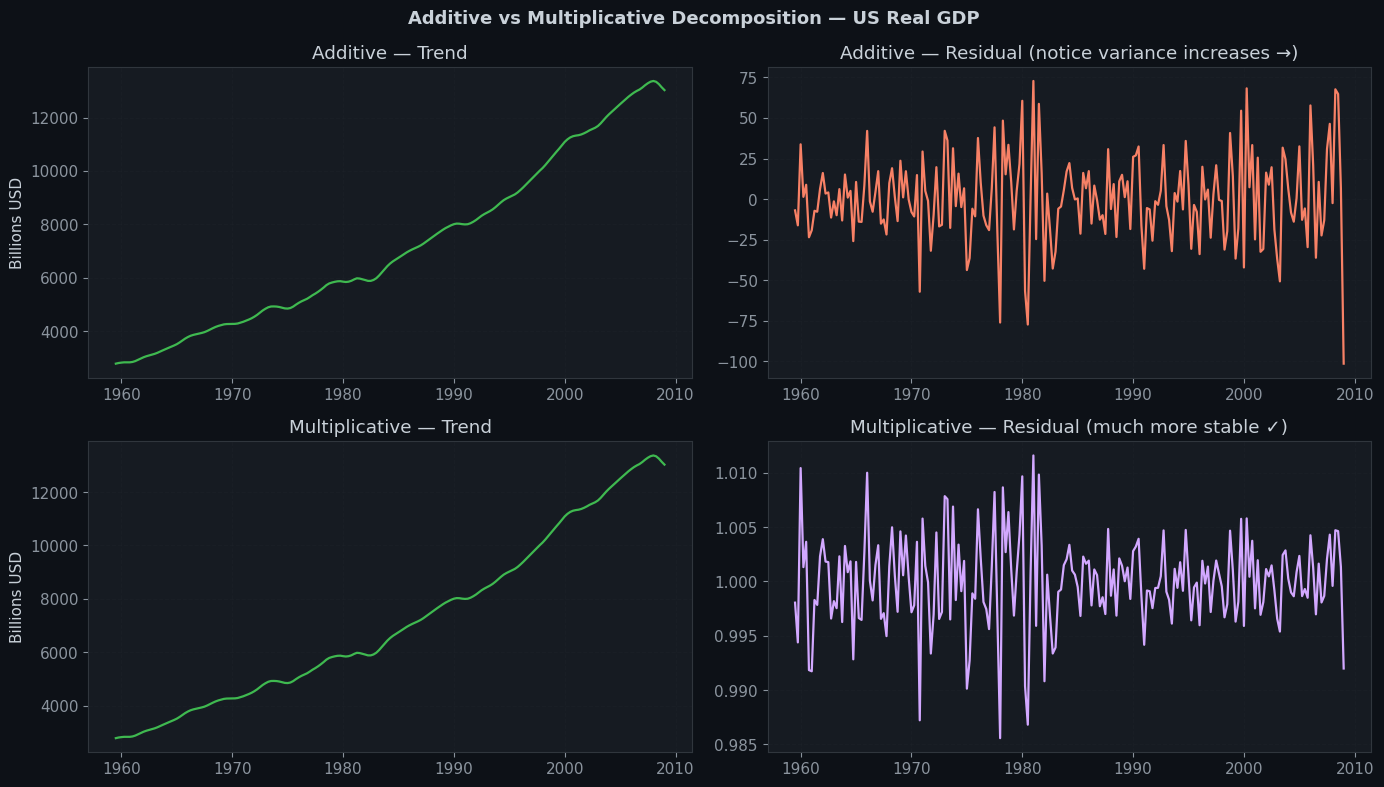

RULE: Use ADDITIVE when seasonality is roughly constant in size.
      Use MULTIPLICATIVE when seasonality grows proportionally with the trend.
Add residual std:  26.7
Mul residual std:  0.0042  ← closer to 0, better fit


In [7]:
# Use GDP to show multiplicative seasonality (variance grows with level)
gdp = macro['realgdp']
gdp.index = pd.DatetimeIndex(gdp.index, freq='QS')

add_decomp  = seasonal_decompose(gdp, model='additive',       period=4)
mul_decomp  = seasonal_decompose(gdp, model='multiplicative', period=4)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Additive vs Multiplicative Decomposition — US Real GDP', fontsize=13, fontweight='bold')

axes[0,0].plot(add_decomp.trend.index,    add_decomp.trend,    color=COLORS[1])
axes[0,0].set_title('Additive — Trend'); axes[0,0].set_ylabel('Billions USD')

axes[0,1].plot(add_decomp.resid.index,    add_decomp.resid,    color=COLORS[2])
axes[0,1].set_title('Additive — Residual (notice variance increases →)')

axes[1,0].plot(mul_decomp.trend.index,    mul_decomp.trend,    color=COLORS[1])
axes[1,0].set_title('Multiplicative — Trend'); axes[1,0].set_ylabel('Billions USD')

axes[1,1].plot(mul_decomp.resid.index,    mul_decomp.resid,    color=COLORS[3])
axes[1,1].set_title('Multiplicative — Residual (much more stable ✓)')

for ax in axes.flat: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('RULE: Use ADDITIVE when seasonality is roughly constant in size.')
print('      Use MULTIPLICATIVE when seasonality grows proportionally with the trend.')
print(f'Add residual std:  {add_decomp.resid.std():.1f}')
print(f'Mul residual std:  {mul_decomp.resid.std():.4f}  ← closer to 0, better fit')

### 2.3 Methods: Classical vs STL

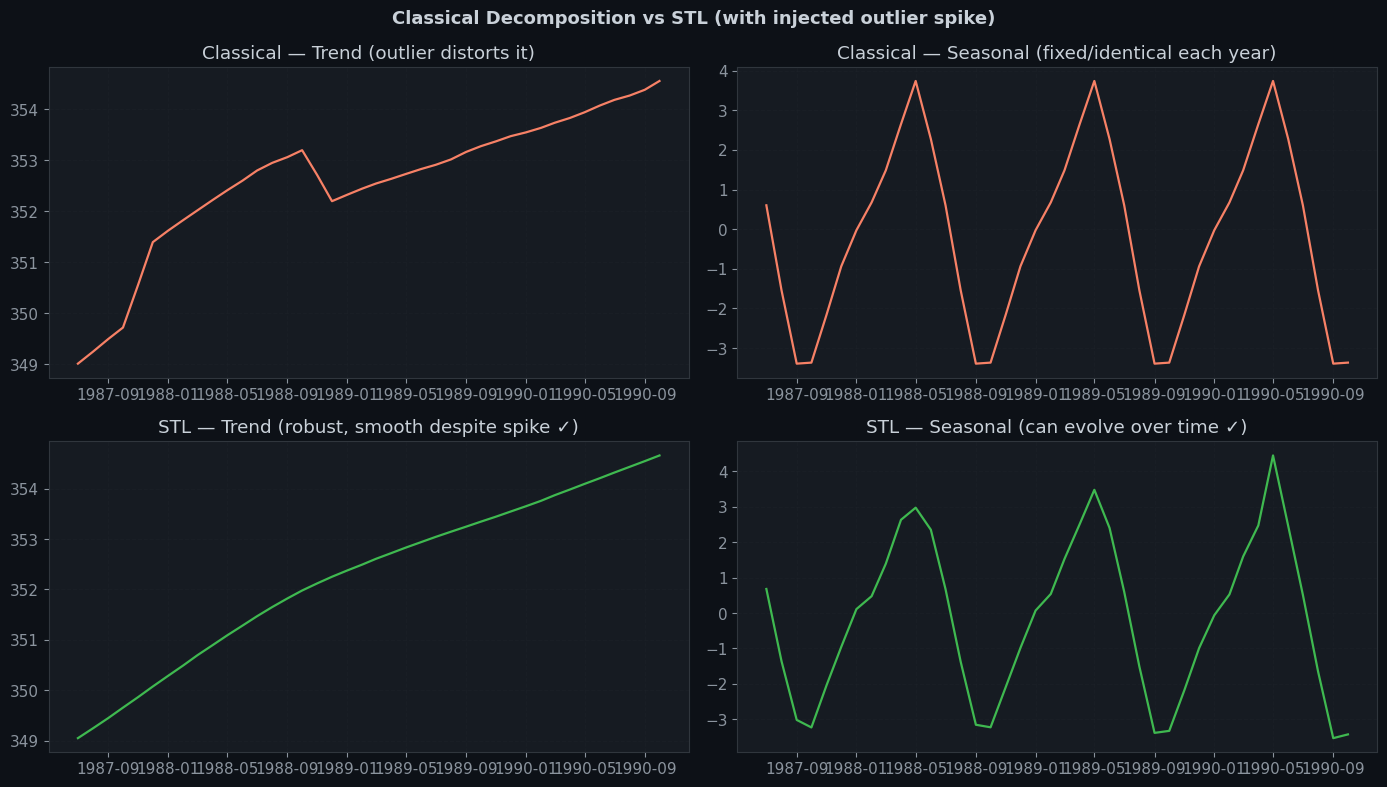

STL advantages:
  • Robust to outliers (uses LOESS smoothing)
  • Seasonal component can change over time
  • Handles any periodicity (not just monthly/quarterly)


In [25]:
# STL is robust to outliers — compare Classical vs STL
co2_stl = co2['co2']['1980':'2001'].copy()

# Inject a fake outlier to show robustness
co2_stl_out = co2_stl.copy()
co2_stl_out.iloc[100] += 15  # spike

classical = seasonal_decompose(co2_stl_out, model='additive', period=12)
stl_result = STL(co2_stl_out, period=12, robust=True).fit()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Classical Decomposition vs STL (with injected outlier spike)', fontsize=13, fontweight='bold')

idx = co2_stl_out.index[90:130]

axes[0,0].plot(classical.trend[90:130].index, classical.trend[90:130], color=COLORS[2])
axes[0,0].set_title('Classical — Trend (outlier distorts it)'); axes[0,0].grid(True,alpha=0.3)

axes[0,1].plot(classical.seasonal[90:130].index, classical.seasonal[90:130], color=COLORS[2])
axes[0,1].set_title('Classical — Seasonal (fixed/identical each year)'); axes[0,1].grid(True,alpha=0.3)

axes[1,0].plot(stl_result.trend[90:130].index, stl_result.trend[90:130], color=COLORS[1])
axes[1,0].set_title('STL — Trend (robust, smooth despite spike ✓)'); axes[1,0].grid(True,alpha=0.3)

axes[1,1].plot(stl_result.seasonal[90:130].index, stl_result.seasonal[90:130], color=COLORS[1])
axes[1,1].set_title('STL — Seasonal (can evolve over time ✓)'); axes[1,1].grid(True,alpha=0.3)

plt.tight_layout(); plt.show()

print('STL advantages:')
print('  • Robust to outliers (uses LOESS smoothing)')
print('  • Seasonal component can change over time')
print('  • Handles any periodicity (not just monthly/quarterly)')

---
## 📐 Section 3 — Stationarity
### 3.1 Types & Properties

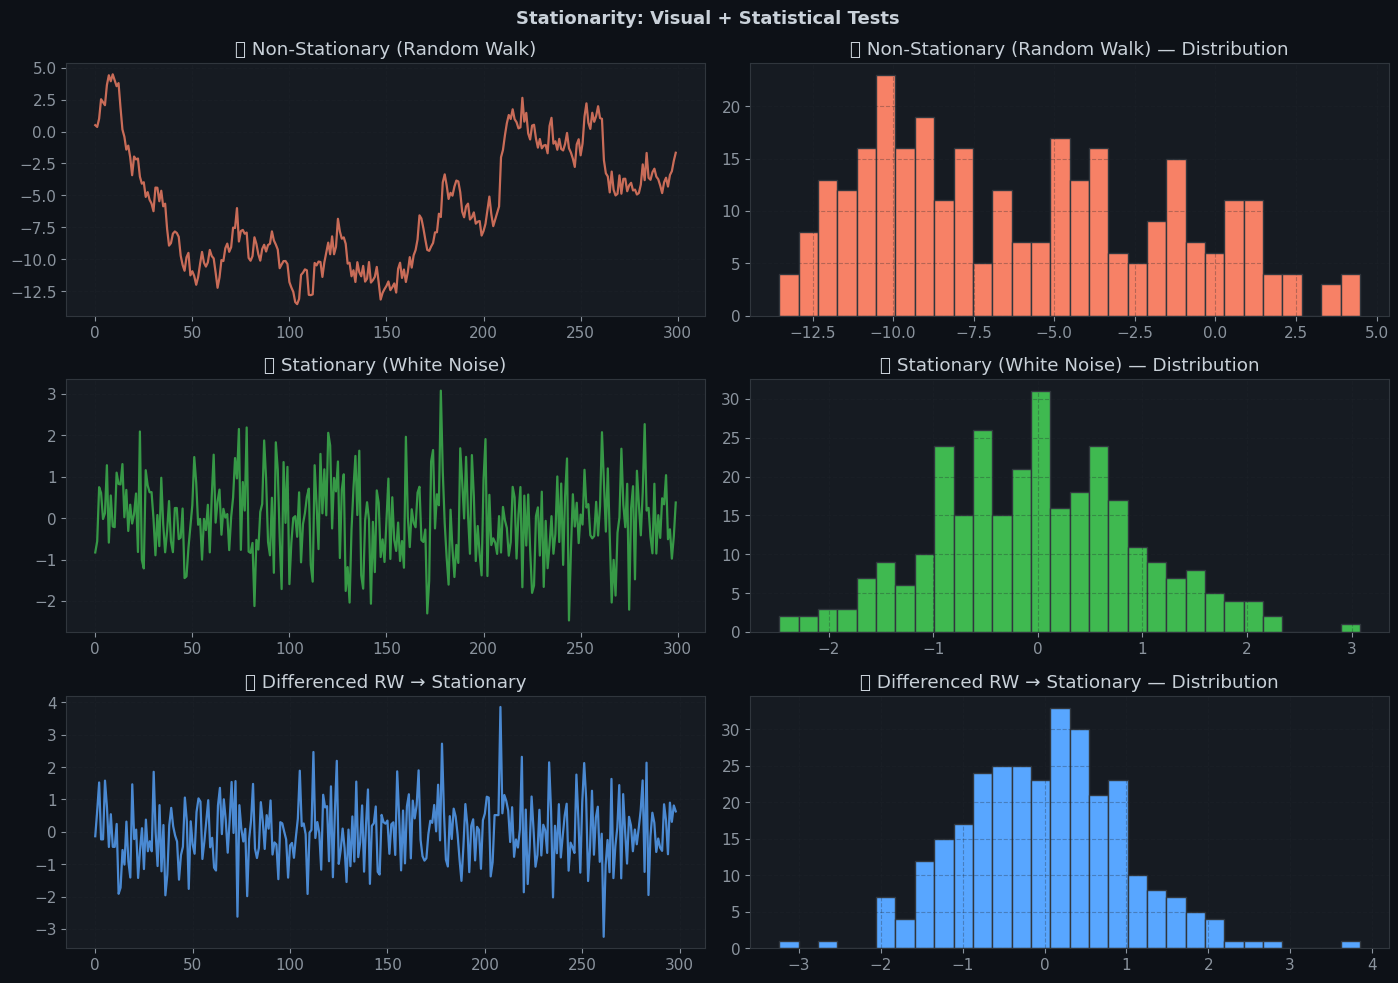

Weak (Covariance) Stationarity requires:
  1. Constant mean E[Xt] = μ
  2. Constant variance Var(Xt) = σ²
  3. Autocovariance depends only on lag, not time

Strict Stationarity: full joint distribution unchanged under time shifts (stronger condition)


In [9]:
# Show stationary vs non-stationary visually
np.random.seed(42)
n = 300

# Non-stationary: random walk (CO₂ is similar)
rw = np.cumsum(np.random.normal(0, 1, n))

# Stationary: white noise
wn = np.random.normal(0, 1, n)

# First difference of random walk → stationary!
rw_diff = np.diff(rw)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Stationarity: Visual + Statistical Tests', fontsize=13, fontweight='bold')

def plot_series_and_hist(ax_ts, ax_hist, data, title, color):
    ax_ts.plot(data, color=color, alpha=0.8)
    ax_ts.set_title(title); ax_ts.grid(True, alpha=0.3)
    ax_hist.hist(data, bins=30, color=color, edgecolor='#30363d')
    ax_hist.set_title(f'{title} — Distribution'); ax_hist.grid(True, alpha=0.3)

plot_series_and_hist(axes[0,0], axes[0,1], rw,      '❌ Non-Stationary (Random Walk)', COLORS[2])
plot_series_and_hist(axes[1,0], axes[1,1], wn,      '✅ Stationary (White Noise)',     COLORS[1])
plot_series_and_hist(axes[2,0], axes[2,1], rw_diff, '✅ Differenced RW → Stationary', COLORS[0])

plt.tight_layout(); plt.show()

print('Weak (Covariance) Stationarity requires:')
print('  1. Constant mean E[Xt] = μ')
print('  2. Constant variance Var(Xt) = σ²')
print('  3. Autocovariance depends only on lag, not time')
print()
print('Strict Stationarity: full joint distribution unchanged under time shifts (stronger condition)')

### 3.2 Statistical Tests: ADF, KPSS, KS

In [10]:
def run_stationarity_tests(series, name):
    """Run ADF + KPSS tests and print summary."""
    print(f'\n{'─'*55}')
    print(f'  Series: {name}')
    print(f'{'─'*55}')
    
    # ADF Test  (H0: unit root = non-stationary)
    adf_stat, adf_p, adf_lags, _, adf_crit, _ = adfuller(series.dropna(), autolag='AIC')
    print(f'  ADF  stat={adf_stat:7.3f}  p={adf_p:.4f}  '
          f'→ {"STATIONARY ✅" if adf_p < 0.05 else "NON-STATIONARY ❌"}  (H0: has unit root)')
    
    # KPSS Test  (H0: stationary)
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'  KPSS stat={kpss_stat:7.3f}  p={kpss_p:.4f}  '
          f'→ {"STATIONARY ✅" if kpss_p > 0.05 else "NON-STATIONARY ❌"}  (H0: is stationary)')

# Raw CO₂ (non-stationary)
run_stationarity_tests(co2['co2'], 'CO₂ — Raw (non-stationary expected)')

# First difference
run_stationarity_tests(co2['co2'].diff(), 'CO₂ — First Difference (stationary expected)')

# Sunspots (mean-reverting but not unit root)
run_stationarity_tests(sunspots['SUNACTIVITY'], 'Sunspot Activity (cyclical, roughly stationary)')

print()
print('INTERPRETATION GUIDE:')
print('  ADF p < 0.05  → reject unit root  → STATIONARY')
print('  KPSS p > 0.05 → fail to reject stationarity → STATIONARY')
print('  Use BOTH tests together for confirmation')


───────────────────────────────────────────────────────
  Series: CO₂ — Raw (non-stationary expected)
───────────────────────────────────────────────────────
  ADF  stat=  2.285  p=0.9989  → NON-STATIONARY ❌  (H0: has unit root)
  KPSS stat=  3.369  p=0.0100  → NON-STATIONARY ❌  (H0: is stationary)

───────────────────────────────────────────────────────
  Series: CO₂ — First Difference (stationary expected)
───────────────────────────────────────────────────────
  ADF  stat= -4.924  p=0.0000  → STATIONARY ✅  (H0: has unit root)
  KPSS stat=  0.297  p=0.1000  → STATIONARY ✅  (H0: is stationary)

───────────────────────────────────────────────────────
  Series: Sunspot Activity (cyclical, roughly stationary)
───────────────────────────────────────────────────────
  ADF  stat= -2.838  p=0.0531  → NON-STATIONARY ❌  (H0: has unit root)
  KPSS stat=  0.670  p=0.0163  → NON-STATIONARY ❌  (H0: is stationary)

INTERPRETATION GUIDE:
  ADF p < 0.05  → reject unit root  → STATIONARY
  KPSS p > 0

### 3.3 Transformation Methods

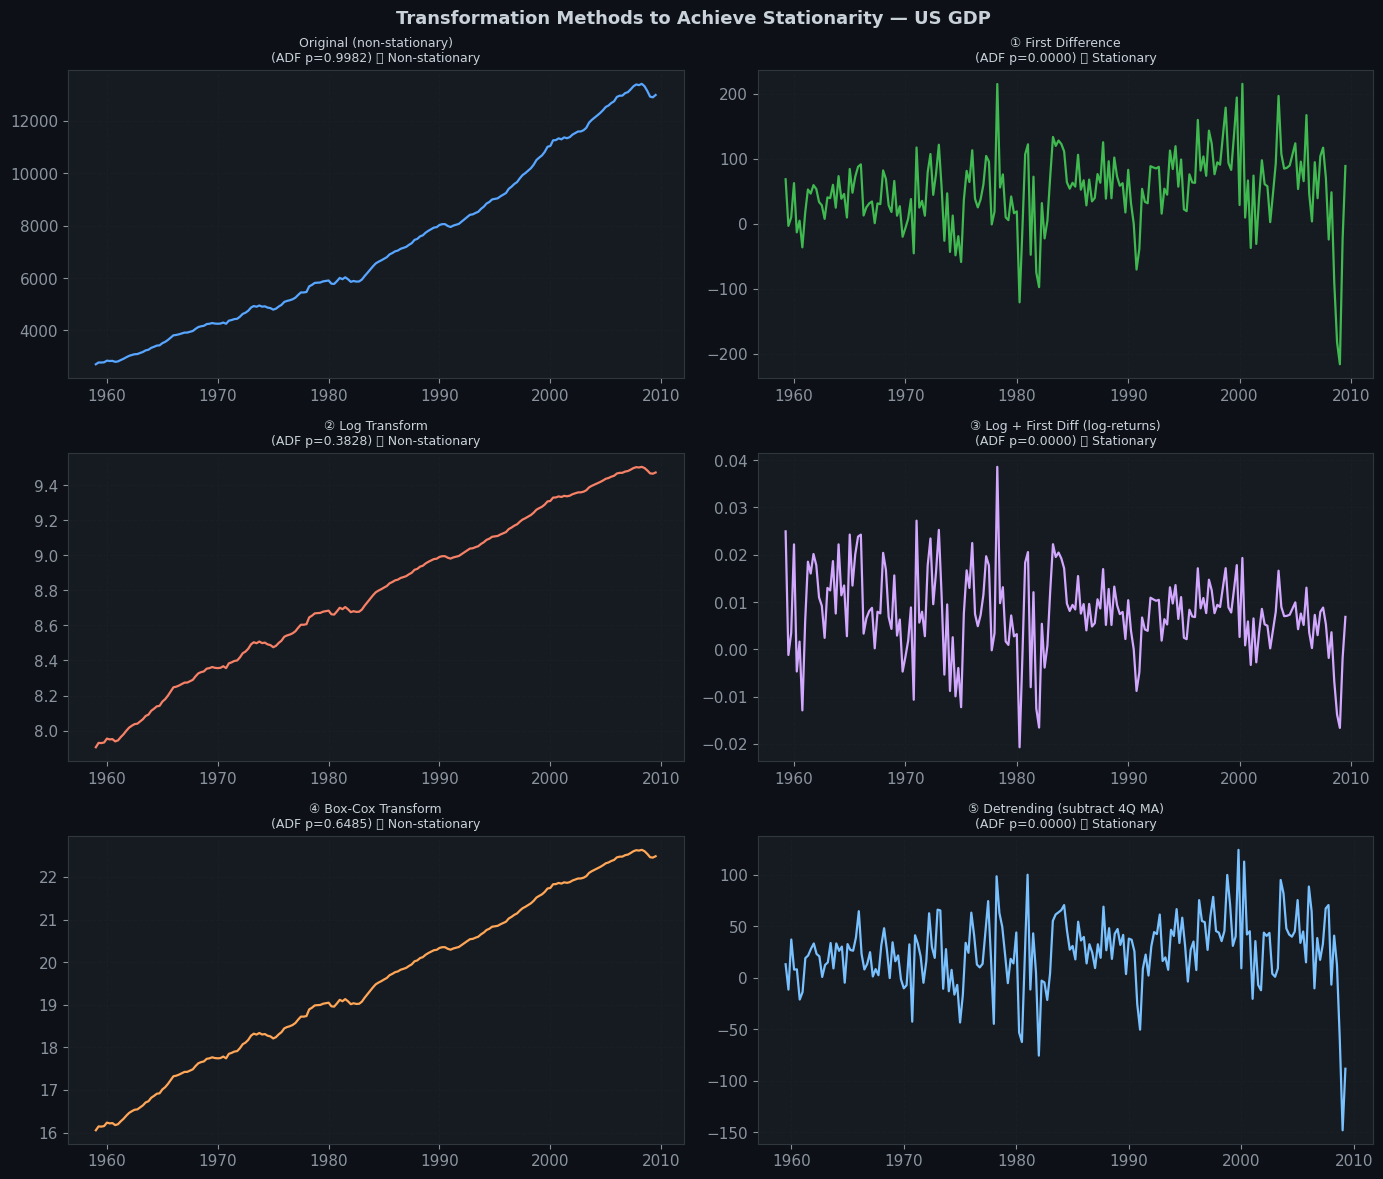

WHEN TO USE EACH:
  Differencing      → removes stochastic trends (unit roots)
  Log transform     → stabilises growing variance
  Box-Cox           → generalises log, finds optimal λ automatically
  Detrending (MA)   → removes deterministic trends
  Seasonal adj      → remove seasonal component before modelling


In [11]:
gdp_ts = macro['realgdp'].copy()
gdp_ts.index = pd.DatetimeIndex(gdp_ts.index, freq='QS')

transformations = {
    'Original (non-stationary)':         gdp_ts,
    '① First Difference':                gdp_ts.diff().dropna(),
    '② Log Transform':                   np.log(gdp_ts),
    '③ Log + First Diff (log-returns)':  np.log(gdp_ts).diff().dropna(),
    '④ Box-Cox Transform':               pd.Series(
                                           stats.boxcox(gdp_ts)[0],
                                           index=gdp_ts.index),
    '⑤ Detrending (subtract 4Q MA)':     gdp_ts - gdp_ts.rolling(4, center=True).mean(),
}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Transformation Methods to Achieve Stationarity — US GDP', fontsize=13, fontweight='bold')

for ax, (name, series) in zip(axes.flat, transformations.items()):
    series_clean = series.dropna()
    ax.plot(series_clean.index, series_clean, color=COLORS[list(transformations.keys()).index(name) % len(COLORS)])
    adf_p = adfuller(series_clean.dropna())[1]
    status = '✅ Stationary' if adf_p < 0.05 else '❌ Non-stationary'
    ax.set_title(f'{name}\n(ADF p={adf_p:.4f}) {status}', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('WHEN TO USE EACH:')
print('  Differencing      → removes stochastic trends (unit roots)')
print('  Log transform     → stabilises growing variance')
print('  Box-Cox           → generalises log, finds optimal λ automatically')
print('  Detrending (MA)   → removes deterministic trends')
print('  Seasonal adj      → remove seasonal component before modelling')

---
## 🔮 Section 4 — Forecasting Models
### 4.1 Model Identification: ACF & PACF

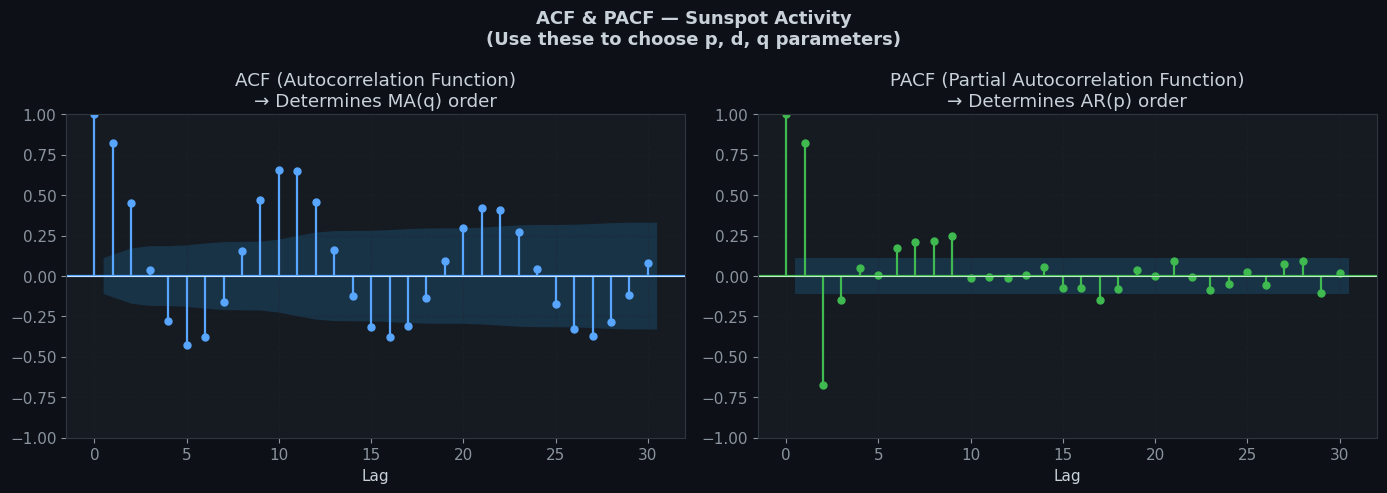

ACF/PACF READING GUIDE:
  Pure AR(p):  PACF cuts off after lag p; ACF tails off
  Pure MA(q):  ACF cuts off after lag q; PACF tails off
  ARMA(p,q):   Both tail off (use AIC/BIC to select order)

  Sunspot ACF shows slow decay → AR component needed
  PACF cuts off around lag 2-3 → AR(2) or AR(3) likely


In [12]:
# Use differenced sunspot series for clean ACF/PACF
series = sunspots['SUNACTIVITY']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ACF & PACF — Sunspot Activity\n(Use these to choose p, d, q parameters)', fontsize=13, fontweight='bold')

plot_acf(series,  lags=30, ax=axes[0], color=COLORS[0], vlines_kwargs={'colors': COLORS[0]})
axes[0].set_title('ACF (Autocorrelation Function)\n→ Determines MA(q) order')
axes[0].set_xlabel('Lag')

plot_pacf(series, lags=30, ax=axes[1], color=COLORS[1], vlines_kwargs={'colors': COLORS[1]}, method='ywm')
axes[1].set_title('PACF (Partial Autocorrelation Function)\n→ Determines AR(p) order')
axes[1].set_xlabel('Lag')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='white', linewidth=0.5)

plt.tight_layout(); plt.show()

print('ACF/PACF READING GUIDE:')
print('  Pure AR(p):  PACF cuts off after lag p; ACF tails off')
print('  Pure MA(q):  ACF cuts off after lag q; PACF tails off')
print('  ARMA(p,q):   Both tail off (use AIC/BIC to select order)')
print()
print('  Sunspot ACF shows slow decay → AR component needed')
print('  PACF cuts off around lag 2-3 → AR(2) or AR(3) likely')

### 4.2 Univariate Models: AR, MA, ARMA, ARIMA, SARIMA

Model Comparison (sorted by RMSE):
       Model    AIC    MAE   RMSE
      SARIMA  285.5  0.873  1.025
ARIMA(2,1,2)  929.6  6.163  7.075
       AR(3) 1058.6 11.090 12.503
   ARMA(2,2) 1054.5 13.485 15.391
       MA(3) 2172.3 31.091 31.491


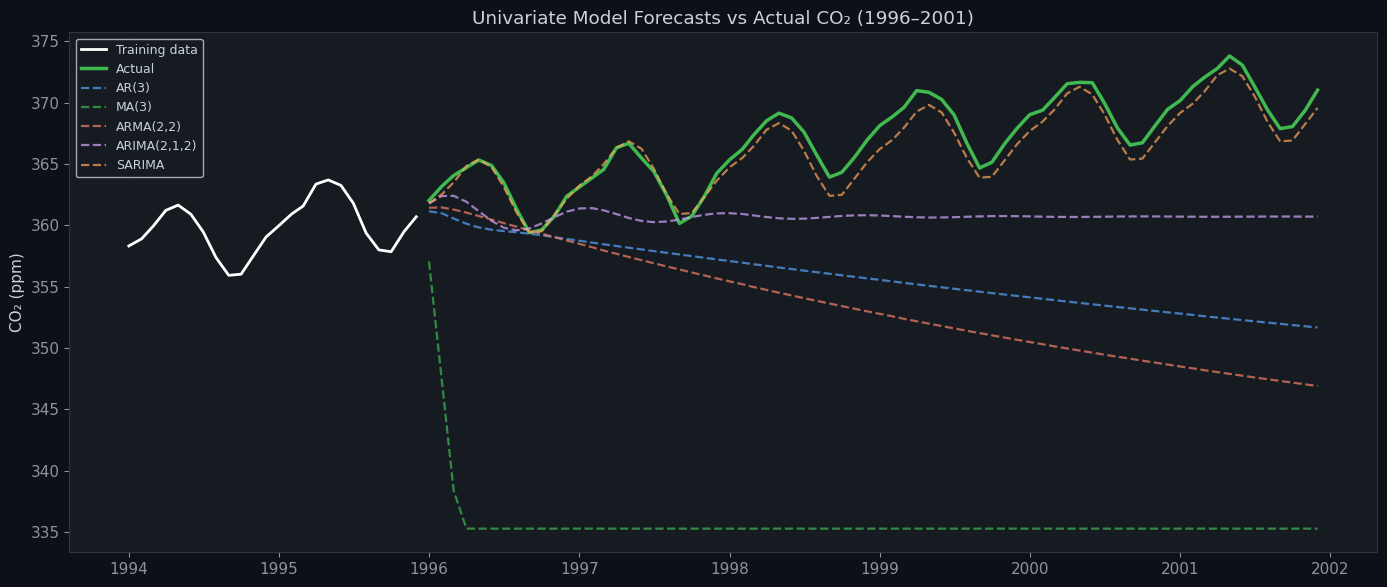

In [14]:
# Fit and compare univariate models on CO₂
train = co2['co2'][:'1995']
test  = co2['co2']['1996':'2001']

models_config = {
    'AR(3)':      ARIMA(train, order=(3,0,0)),
    'MA(3)':      ARIMA(train, order=(0,0,3)),
    'ARMA(2,2)':  ARIMA(train, order=(2,0,2)),
    'ARIMA(2,1,2)': ARIMA(train, order=(2,1,2)),
    'SARIMA':     SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,12)),
}

results_table = []
fitted_models = {}
for name, model in models_config.items():
    fit = model.fit()
    fc = fit.forecast(steps=len(test))
    mae_val  = mean_absolute_error(test, fc)
    rmse_val = np.sqrt(mean_squared_error(test, fc))
    results_table.append({'Model': name, 'AIC': round(fit.aic,1), 'MAE': round(mae_val,3), 'RMSE': round(rmse_val,3)})
    fitted_models[name] = fc

results_df = pd.DataFrame(results_table).sort_values('RMSE')
print('Model Comparison (sorted by RMSE):')
print(results_df.to_string(index=False))

# Plot forecasts
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train[-24:].index, train[-24:], color='white', linewidth=2, label='Training data')
ax.plot(test.index, test, color=COLORS[1], linewidth=2.5, label='Actual')
for (name, fc), color in zip(fitted_models.items(), COLORS):
    ax.plot(test.index, fc, '--', color=color, alpha=0.7, label=name)

ax.set_title('Univariate Model Forecasts vs Actual CO₂ (1996–2001)')
ax.set_ylabel('CO₂ (ppm)'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 4.3 Multivariate Models: VAR, VMA, VARMA

VAR selected lag order: 1

VAR Summary (short):
  Variables: GDP growth, Consumption growth, Investment growth
  AIC: -0.37


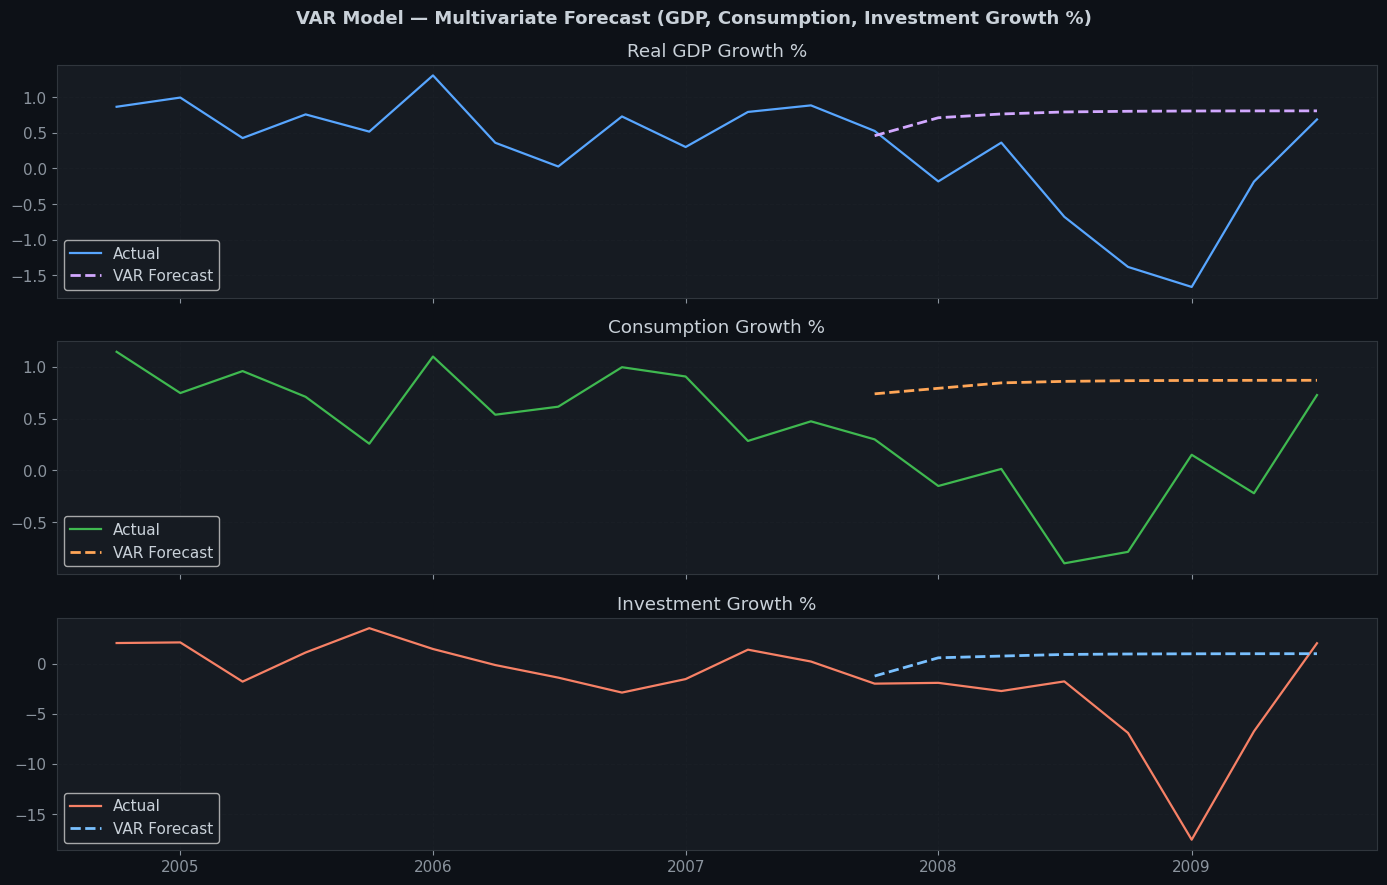


VAR KEY IDEA: Each variable is regressed on lagged values of ALL variables.
This captures cross-variable dynamics (e.g., investment predicts future GDP)


In [15]:
# VAR on macroeconomic variables
macro_subset = macro[['realgdp', 'realcons', 'realinv']].copy()
macro_subset.index = pd.DatetimeIndex(macro_subset.index, freq='QS')

# Make stationary via log-differencing
macro_diff = np.log(macro_subset).diff().dropna() * 100  # quarterly growth rates

# Train/test split
n_test = 8
macro_train = macro_diff.iloc[:-n_test]
macro_test  = macro_diff.iloc[-n_test:]

# Fit VAR
var_model = VAR(macro_train)
var_result = var_model.fit(maxlags=4, ic='aic')
print(f'VAR selected lag order: {var_result.k_ar}')
print(f'\nVAR Summary (short):')
print(f'  Variables: GDP growth, Consumption growth, Investment growth')
print(f'  AIC: {var_result.aic:.2f}')

# Forecast
fc = var_result.forecast(macro_train.values[-var_result.k_ar:], steps=n_test)
fc_df = pd.DataFrame(fc, index=macro_test.index, columns=macro_diff.columns)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('VAR Model — Multivariate Forecast (GDP, Consumption, Investment Growth %)', fontsize=13, fontweight='bold')

labels = ['Real GDP Growth %', 'Consumption Growth %', 'Investment Growth %']
for i, (ax, col, label) in enumerate(zip(axes, macro_diff.columns, labels)):
    ax.plot(macro_diff.index[-20:], macro_diff[col].iloc[-20:], color=COLORS[i], label='Actual')
    ax.plot(fc_df.index, fc_df[col], '--', color=COLORS[i+3], linewidth=2, label='VAR Forecast')
    ax.set_title(label); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('\nVAR KEY IDEA: Each variable is regressed on lagged values of ALL variables.')
print('This captures cross-variable dynamics (e.g., investment predicts future GDP)')

---
## 🧹 Section 5 — Smoothing Methods
### 5.1 Moving Averages: Simple, Weighted, Exponential

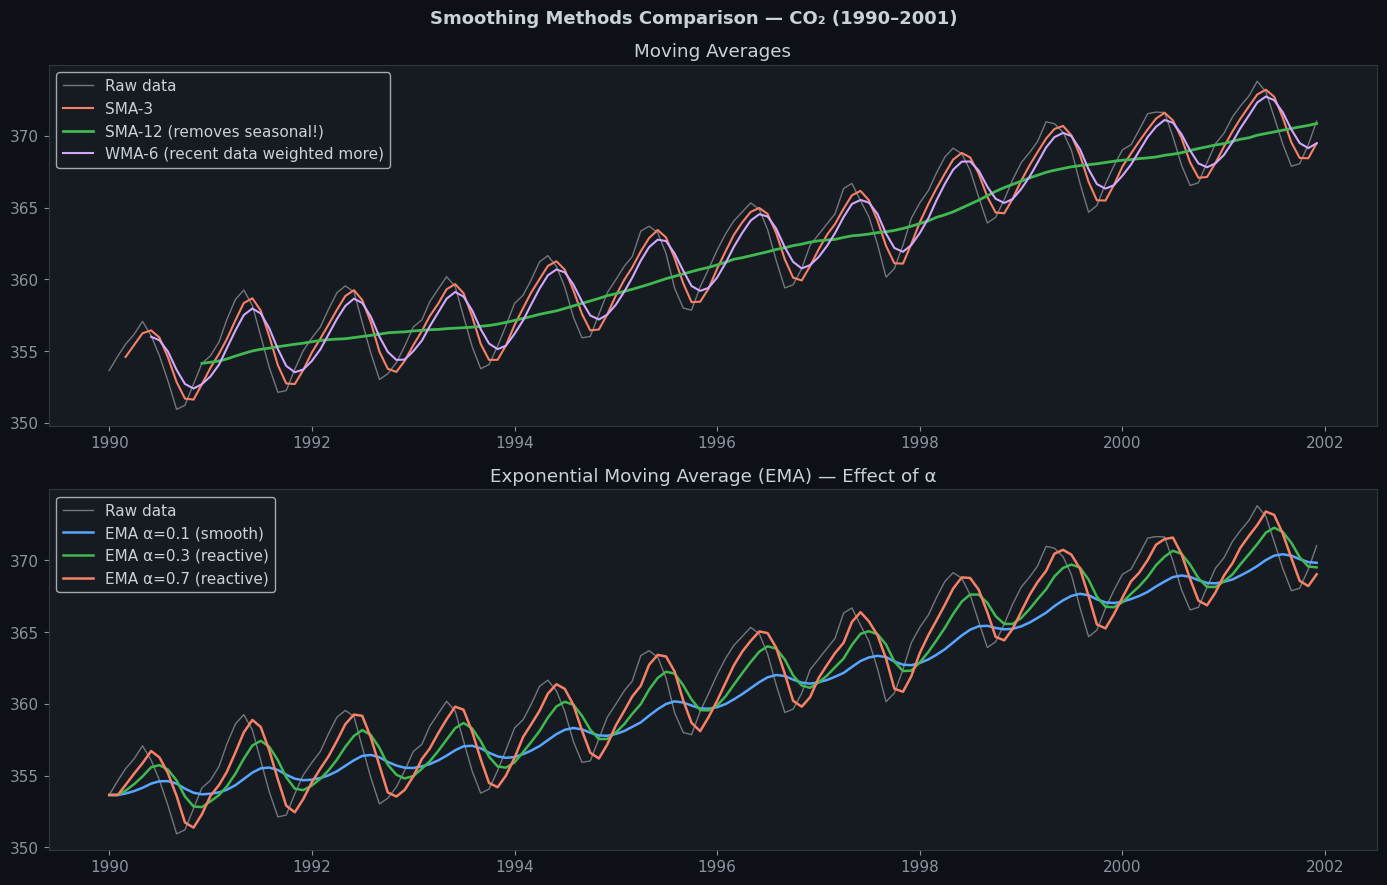

SMA: Each point equally weighted in window
WMA: More recent points get higher weights
EMA: Exponentially decaying weights — α controls smoothness
  α → 0 : very smooth, slow to react
  α → 1 : barely smoothed, very reactive to noise


In [16]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

co2_slice = co2['co2']['1990':'2001']

# Moving averages
sma_3  = co2_slice.rolling(3).mean()
sma_12 = co2_slice.rolling(12).mean()
wma_weights = np.arange(1, 7)
wma = co2_slice.rolling(6).apply(lambda x: np.dot(x, wma_weights/wma_weights.sum()))

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Smoothing Methods Comparison — CO₂ (1990–2001)', fontsize=13, fontweight='bold')

# Moving averages
axes[0].plot(co2_slice.index, co2_slice,  color='white',   alpha=0.4, linewidth=1,   label='Raw data')
axes[0].plot(sma_3.index,    sma_3,       color=COLORS[2], linewidth=1.5, label='SMA-3')
axes[0].plot(sma_12.index,   sma_12,      color=COLORS[1], linewidth=2,   label='SMA-12 (removes seasonal!)')
axes[0].plot(wma.index,      wma,         color=COLORS[3], linewidth=1.5, label='WMA-6 (recent data weighted more)')
axes[0].set_title('Moving Averages')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Exponential smoothing with different alphas
axes[1].plot(co2_slice.index, co2_slice, color='white', alpha=0.4, linewidth=1, label='Raw data')
for alpha, color in zip([0.1, 0.3, 0.7], [COLORS[0], COLORS[1], COLORS[2]]):
    ema = SimpleExpSmoothing(co2_slice).fit(smoothing_level=alpha, optimized=False)
    axes[1].plot(co2_slice.index, ema.fittedvalues, color=color, linewidth=1.8,
                 label=f'EMA α={alpha} ({"smooth" if alpha<0.3 else "reactive"})')

axes[1].set_title('Exponential Moving Average (EMA) — Effect of α')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('SMA: Each point equally weighted in window')
print('WMA: More recent points get higher weights')
print('EMA: Exponentially decaying weights — α controls smoothness')
print('  α → 0 : very smooth, slow to react')
print('  α → 1 : barely smoothed, very reactive to noise')

### 5.2 Exponential Smoothing: Holt's & Holt-Winters

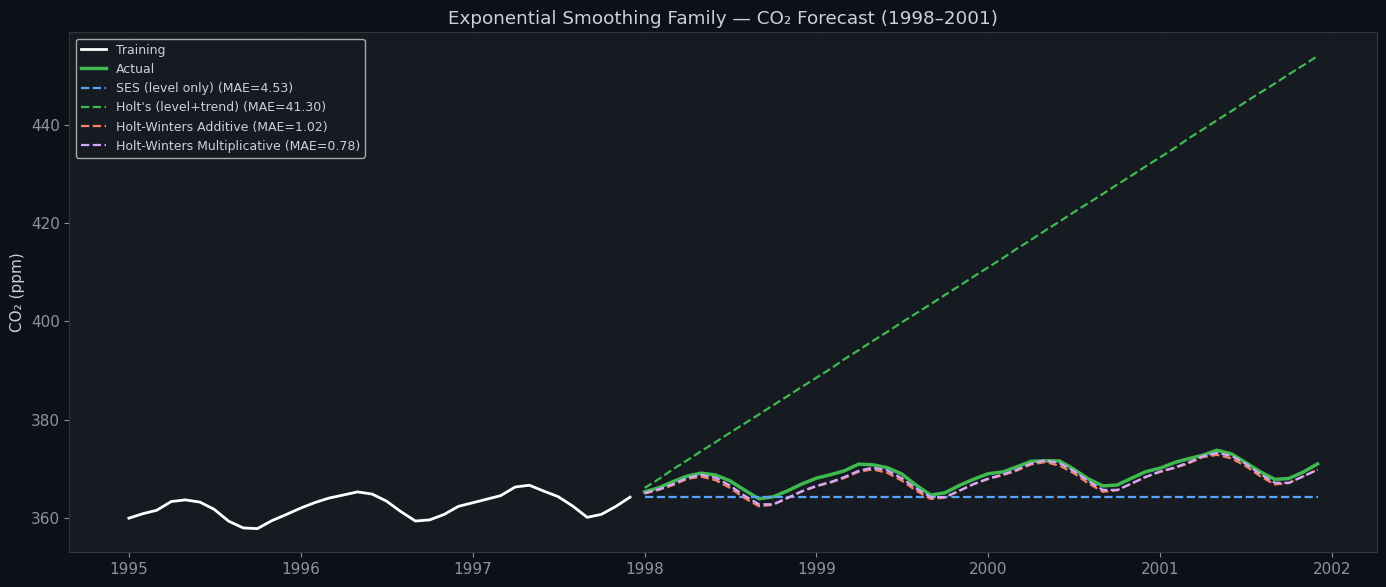

SES:    Models only level → flat forecast (just predicts the mean)
Holt's: Models level + trend → linear forecast
HW:     Models level + trend + seasonality → best for seasonal data


In [17]:
train_co2 = co2['co2'][:'1997']
test_co2  = co2['co2']['1998':'2001']

# Three levels of exponential smoothing
ses    = SimpleExpSmoothing(train_co2).fit(optimized=True)
holts  = ExponentialSmoothing(train_co2, trend='add').fit(optimized=True)
hw_add = ExponentialSmoothing(train_co2, trend='add', seasonal='add',   seasonal_periods=12).fit(optimized=True)
hw_mul = ExponentialSmoothing(train_co2, trend='add', seasonal='mul', seasonal_periods=12).fit(optimized=True)

n = len(test_co2)
forecasts = {
    'SES (level only)':          ses.forecast(n),
    "Holt's (level+trend)":      holts.forecast(n),
    'Holt-Winters Additive':     hw_add.forecast(n),
    'Holt-Winters Multiplicative': hw_mul.forecast(n),
}

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_co2[-36:].index, train_co2[-36:], color='white', linewidth=2, label='Training')
ax.plot(test_co2.index, test_co2, color=COLORS[1], linewidth=2.5, label='Actual')
for (name, fc), color in zip(forecasts.items(), COLORS):
    mae_v = mean_absolute_error(test_co2, fc)
    ax.plot(test_co2.index, fc, '--', color=color, label=f'{name} (MAE={mae_v:.2f})')

ax.set_title('Exponential Smoothing Family — CO₂ Forecast (1998–2001)')
ax.set_ylabel('CO₂ (ppm)'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('SES:    Models only level → flat forecast (just predicts the mean)')
print("Holt's: Models level + trend → linear forecast")
print('HW:     Models level + trend + seasonality → best for seasonal data')

---
## 📏 Section 6 — Evaluation Metrics

Comprehensive Evaluation Metrics:
                      Model    MAE      MSE   RMSE   MAPE%     AIC
           SES (level only)  4.527   26.040  5.103  1.2235   171.6
       Holt's (level+trend) 41.302 2316.123 48.126 11.1802   -62.8
      Holt-Winters Additive  1.019    1.161  1.078  0.2766 -1018.4
Holt-Winters Multiplicative  0.777    0.755  0.869  0.2109 -1073.9


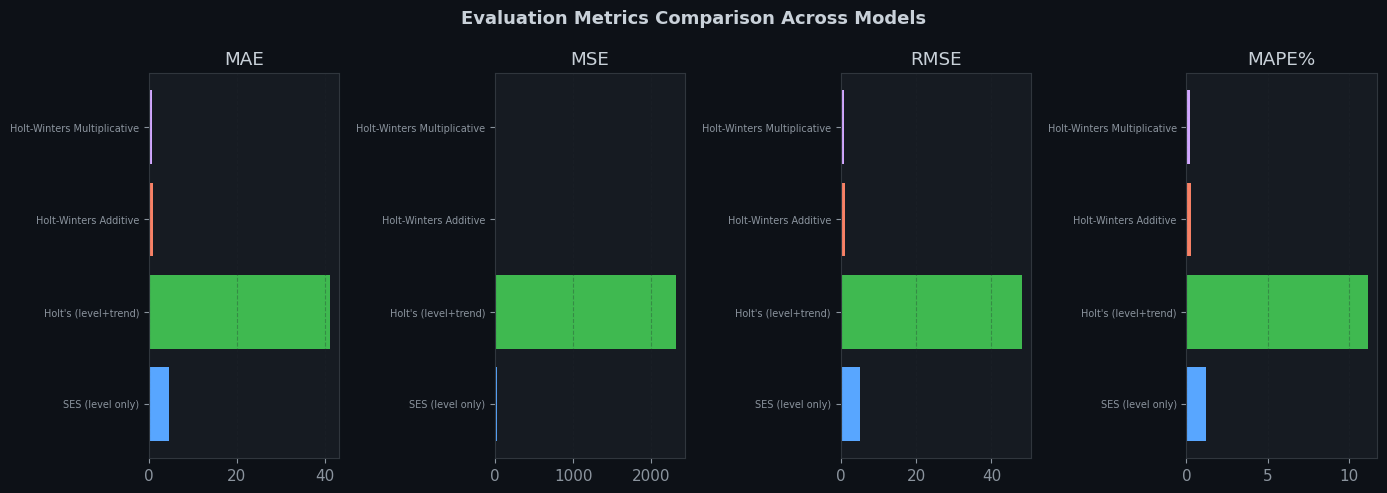


METRIC GUIDE:
  MAE   — Mean Abs Error: interpretable in original units, robust to outliers
  MSE   — Mean Sq Error:  penalises large errors heavily
  RMSE  — Root MSE:       interpretable in original units, sensitive to outliers
  MAPE% — % error:        scale-free, good for comparing across series
  AIC   — Model selection: penalises complexity, lower is better
  BIC   — Like AIC but heavier complexity penalty


In [18]:
# Compute all 6 metrics for each model
test_vals = test_co2.values

def compute_metrics(actual, predicted, model_name, aic_val=None):
    mae_  = mean_absolute_error(actual, predicted)
    mse_  = mean_squared_error(actual, predicted)
    rmse_ = np.sqrt(mse_)
    mape_ = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'Model': model_name, 'MAE': round(mae_,3), 'MSE': round(mse_,3),
            'RMSE': round(rmse_,3), 'MAPE%': round(mape_,4), 'AIC': aic_val}

# Models fitted earlier
metric_rows = []
for (name, fc), model_obj in zip(forecasts.items(), [ses, holts, hw_add, hw_mul]):
    metric_rows.append(compute_metrics(test_vals, fc.values, name, round(model_obj.aic, 1)))

metrics_df = pd.DataFrame(metric_rows)
print('Comprehensive Evaluation Metrics:')
print(metrics_df.to_string(index=False))

# Visualise metrics
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle('Evaluation Metrics Comparison Across Models', fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['MAE', 'MSE', 'RMSE', 'MAPE%']):
    bars = ax.barh(metrics_df['Model'], metrics_df[metric],
                   color=COLORS[:len(metrics_df)])
    ax.set_title(metric); ax.grid(True, alpha=0.3, axis='x')
    ax.tick_params(axis='y', labelsize=7)

plt.tight_layout(); plt.show()

print()
print('METRIC GUIDE:')
print('  MAE   — Mean Abs Error: interpretable in original units, robust to outliers')
print('  MSE   — Mean Sq Error:  penalises large errors heavily')
print('  RMSE  — Root MSE:       interpretable in original units, sensitive to outliers')
print('  MAPE% — % error:        scale-free, good for comparing across series')
print('  AIC   — Model selection: penalises complexity, lower is better')
print('  BIC   — Like AIC but heavier complexity penalty')

---
## 🛠️ Section 7 — Data Pre-processing
### 7.1 Missing Values

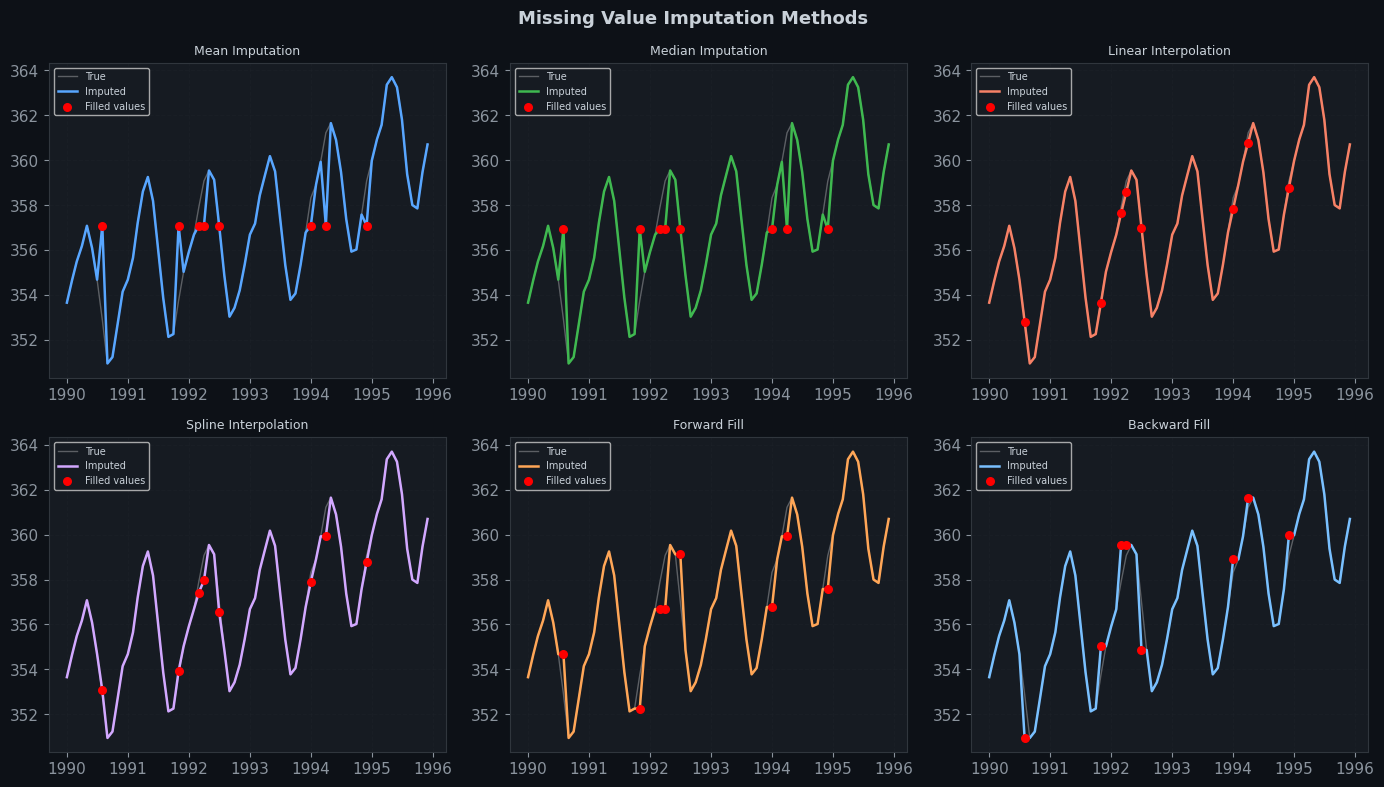

Imputation Accuracy (MAE vs true values at missing points):
  Mean Imputation              MAE = 2.221
  Median Imputation            MAE = 2.279
  Linear Interpolation         MAE = 0.270
  Spline Interpolation         MAE = 0.550
  Forward Fill                 MAE = 1.666
  Backward Fill                MAE = 1.177


In [19]:
# Simulate missing values in CO₂ and compare imputation methods
np.random.seed(0)
co2_sample = co2['co2']['1990':'1995'].copy()
missing_idx = np.random.choice(len(co2_sample), size=8, replace=False)
co2_missing = co2_sample.copy()
co2_missing.iloc[missing_idx] = np.nan

# Imputation methods
imputed = pd.DataFrame(index=co2_sample.index)
imputed['original']      = co2_sample
imputed['with_gaps']     = co2_missing
imputed['mean_imputed']  = co2_missing.fillna(co2_missing.mean())
imputed['median_imputed']= co2_missing.fillna(co2_missing.median())
imputed['linear_interp'] = co2_missing.interpolate(method='linear')
imputed['spline_interp'] = co2_missing.interpolate(method='spline', order=3)
imputed['ffill']         = co2_missing.ffill()
imputed['bfill']         = co2_missing.bfill()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Missing Value Imputation Methods', fontsize=13, fontweight='bold')

methods = ['mean_imputed', 'median_imputed', 'linear_interp', 'spline_interp', 'ffill', 'bfill']
titles  = ['Mean Imputation', 'Median Imputation', 'Linear Interpolation', 'Spline Interpolation', 'Forward Fill', 'Backward Fill']

for ax, method, title in zip(axes.flat, methods, titles):
    ax.plot(imputed['original'].index, imputed['original'], color='white', alpha=0.3, linewidth=1, label='True')
    ax.plot(imputed[method].index,    imputed[method],     color=COLORS[methods.index(method)%len(COLORS)], linewidth=1.8, label='Imputed')
    ax.scatter(imputed.index[missing_idx], imputed[method].iloc[missing_idx], color='red', s=30, zorder=5, label='Filled values')
    ax.set_title(title, fontsize=9); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Accuracy of each method
print('Imputation Accuracy (MAE vs true values at missing points):')
for method, title in zip(methods, titles):
    mae_val = mean_absolute_error(co2_sample.iloc[missing_idx], imputed[method].iloc[missing_idx])
    print(f'  {title:<28} MAE = {mae_val:.3f}')

### 7.2 Outlier Handling

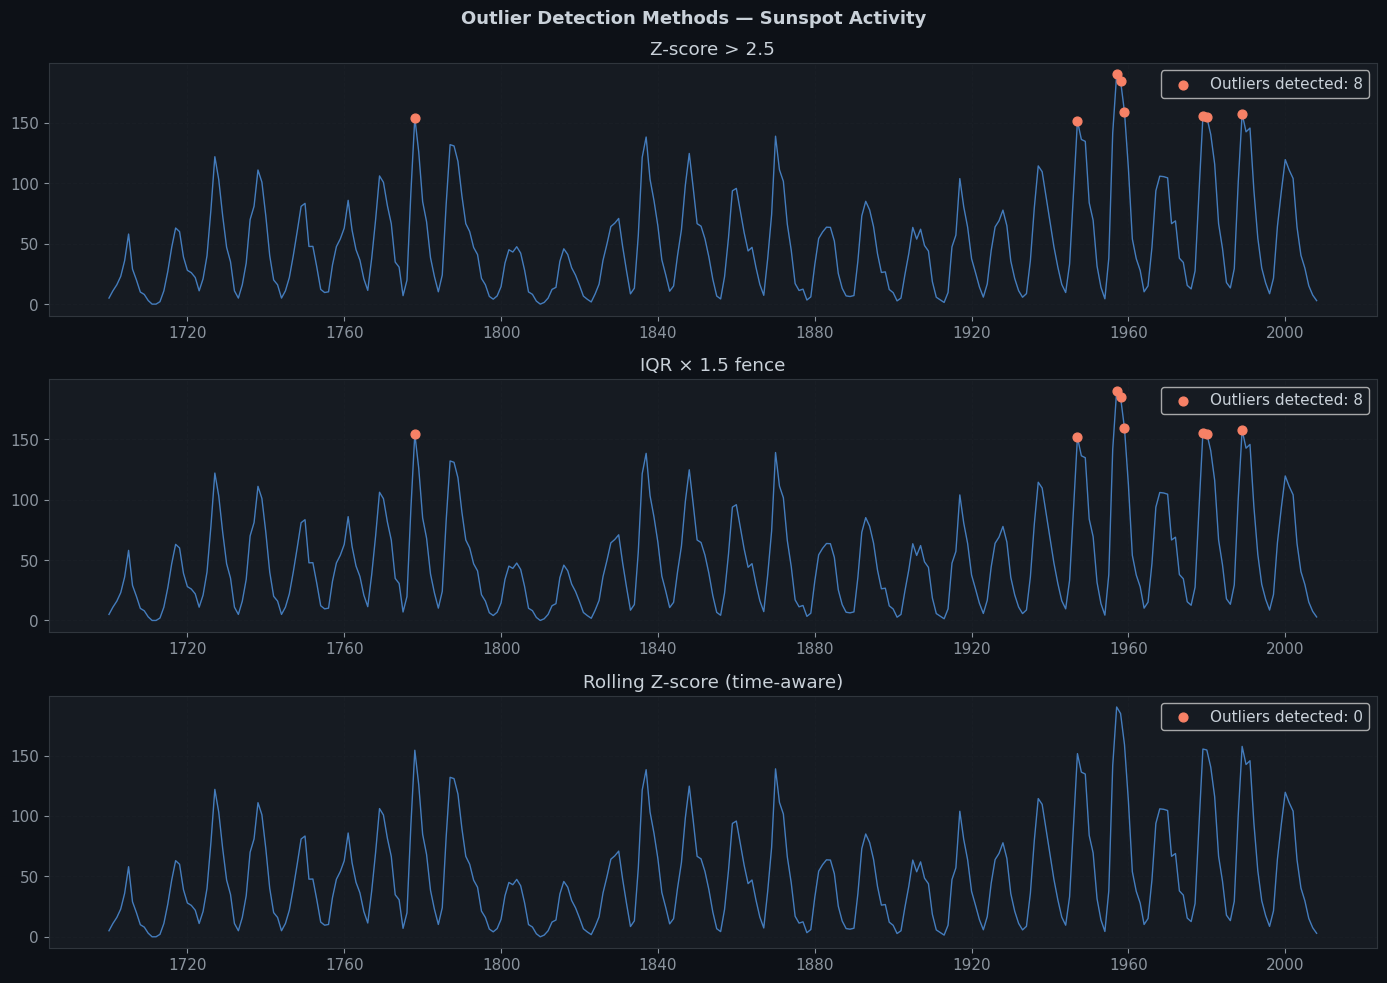

OUTLIER HANDLING OPTIONS:
  1. Remove   → set to NaN, then interpolate
  2. Winsorize → cap at percentile thresholds
  3. Transform → log/sqrt reduces impact of extreme values
  4. Keep      → use robust models (STL with robust=True, quantile regression)


In [20]:
# Detect and handle outliers in sunspot data
sun = sunspots['SUNACTIVITY'].copy()

# Method 1: Z-score
z_scores = np.abs(stats.zscore(sun))
z_outliers = sun[z_scores > 2.5]

# Method 2: IQR
Q1, Q3 = sun.quantile(0.25), sun.quantile(0.75)
IQR = Q3 - Q1
iqr_outliers = sun[(sun < Q1 - 1.5*IQR) | (sun > Q3 + 1.5*IQR)]

# Method 3: Rolling z-score (time-aware)
rolling_mean = sun.rolling(11, center=True).mean()
rolling_std  = sun.rolling(11, center=True).std()
rolling_z    = (sun - rolling_mean).abs() / rolling_std
rolling_outliers = sun[rolling_z > 2.5]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Outlier Detection Methods — Sunspot Activity', fontsize=13, fontweight='bold')

for ax, outliers, method in zip(axes,
    [z_outliers, iqr_outliers, rolling_outliers],
    ['Z-score > 2.5', 'IQR × 1.5 fence', 'Rolling Z-score (time-aware)']):
    ax.plot(sun.index, sun, color=COLORS[0], alpha=0.7, linewidth=1)
    ax.scatter(outliers.index, outliers, color=COLORS[2], s=40, zorder=5,
               label=f'Outliers detected: {len(outliers)}')
    ax.set_title(method); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('OUTLIER HANDLING OPTIONS:')
print('  1. Remove   → set to NaN, then interpolate')
print('  2. Winsorize → cap at percentile thresholds')
print('  3. Transform → log/sqrt reduces impact of extreme values')
print('  4. Keep      → use robust models (STL with robust=True, quantile regression)')

### 7.3 Resampling: Upsampling & Downsampling

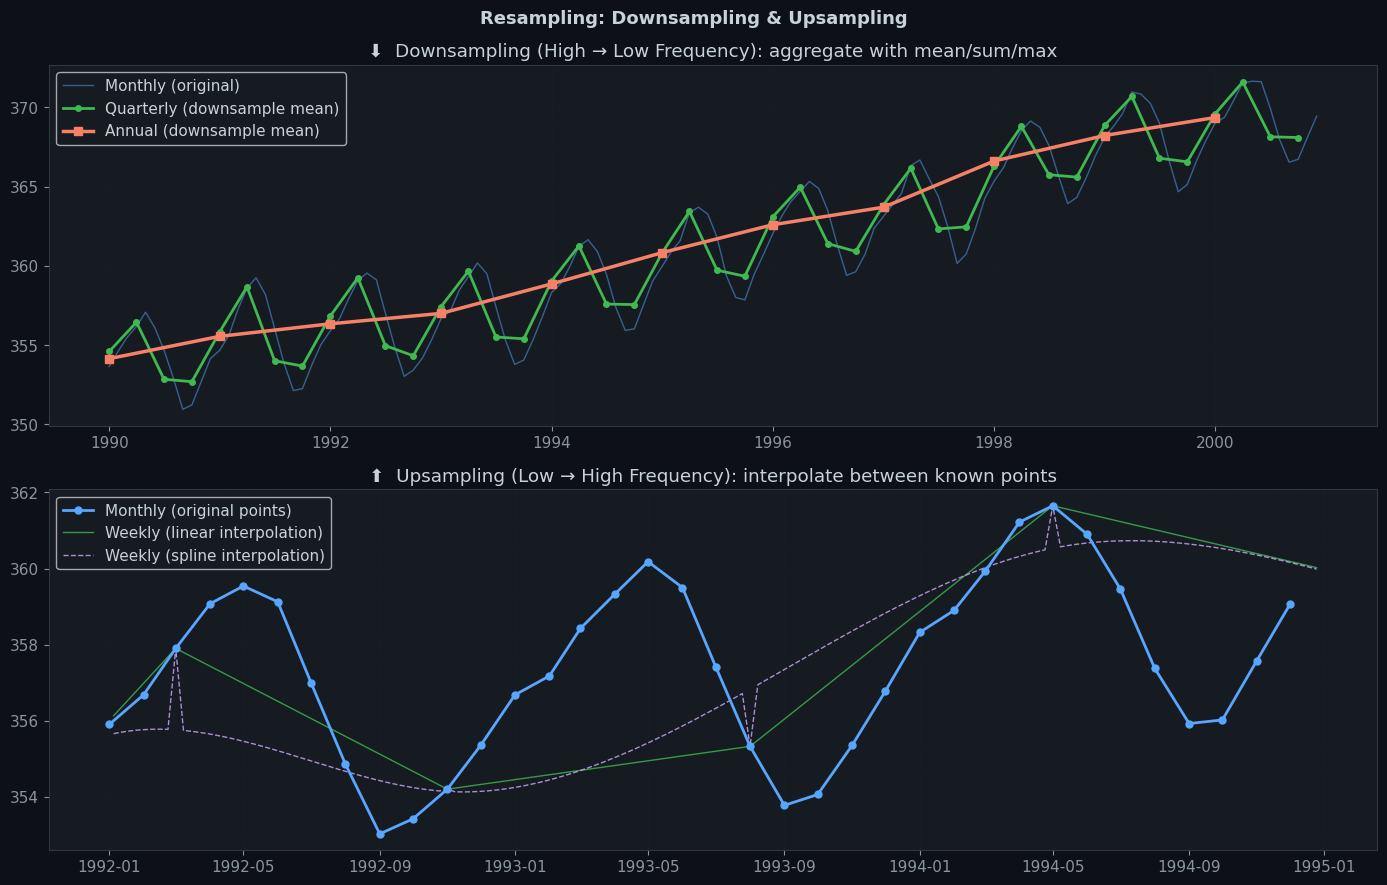

RESAMPLING RULES:
  Downsampling: aggregate (mean, sum, last, max) → safe, loses info
  Upsampling:   interpolate (linear, spline, forward-fill) → infers info
  Monthly → Weekly: 132 → 570 observations


In [21]:
# Demonstrate resampling with CO₂ data
co2_monthly = co2['co2']['1990':'2000']  # base: monthly

# Downsampling (monthly → quarterly → annual)
co2_quarterly = co2_monthly.resample('QS').mean()
co2_annual    = co2_monthly.resample('AS').mean()

# Upsampling (monthly → weekly via interpolation)
co2_weekly_linear = co2_monthly.resample('W').interpolate(method='linear')
co2_weekly_spline = co2_monthly.resample('W').interpolate(method='spline', order=3)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Resampling: Downsampling & Upsampling', fontsize=13, fontweight='bold')

# Downsampling
ax = axes[0]
ax.plot(co2_monthly.index,   co2_monthly,   color=COLORS[0], alpha=0.5, linewidth=1, label='Monthly (original)')
ax.plot(co2_quarterly.index, co2_quarterly, color=COLORS[1], marker='o', markersize=4, linewidth=2, label='Quarterly (downsample mean)')
ax.plot(co2_annual.index,    co2_annual,    color=COLORS[2], marker='s', markersize=6, linewidth=2.5, label='Annual (downsample mean)')
ax.set_title('⬇️  Downsampling (High → Low Frequency): aggregate with mean/sum/max')
ax.legend(); ax.grid(True, alpha=0.3)

# Upsampling
ax = axes[1]
sample_slice = co2_monthly['1992':'1994']
ax.plot(sample_slice.index, sample_slice, color=COLORS[0], marker='o', markersize=5, linewidth=2, label='Monthly (original points)', zorder=5)
wl = co2_weekly_linear['1992':'1994']
ws = co2_weekly_spline['1992':'1994']
ax.plot(wl.index, wl, color=COLORS[1], linewidth=1, alpha=0.8, label='Weekly (linear interpolation)')
ax.plot(ws.index, ws, color=COLORS[3], linewidth=1, alpha=0.8, linestyle='--', label='Weekly (spline interpolation)')
ax.set_title('⬆️  Upsampling (Low → High Frequency): interpolate between known points')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('RESAMPLING RULES:')
print('  Downsampling: aggregate (mean, sum, last, max) → safe, loses info')
print('  Upsampling:   interpolate (linear, spline, forward-fill) → infers info')
print(f'  Monthly → Weekly: {len(co2_monthly)} → {len(co2_weekly_linear)} observations')

---
## 🏁 Section 8 — Full End-to-End Pipeline

In [22]:
print('=' * 60)
print('  END-TO-END TIME SERIES PIPELINE CHECKLIST')
print('=' * 60)

pipeline = [
    ('1. Load & Inspect',    ['Check shape, dtype, index frequency', 'Plot the raw series', 'Check for missing values']),
    ('2. Pre-process',       ['Handle missing values (interpolate)', 'Handle outliers (winsorize / remove)', 'Resample if needed']),
    ('3. Decompose',         ['Additive or multiplicative?', 'Plot trend, seasonal, residual', 'Use STL for robustness']),
    ('4. Stationarity',      ['ADF + KPSS tests', 'Difference / log-transform if needed', 'Re-test until stationary']),
    ('5. Plot ACF/PACF',     ['Identify p, q orders', 'Check for seasonality in ACF']),
    ('6. Fit Models',        ['Start simple (ARIMA)', 'Add seasonality (SARIMA)', 'Try Holt-Winters, Prophet, etc.']),
    ('7. Evaluate',          ['MAE, RMSE, MAPE on test set', 'AIC/BIC for model selection', 'Residual diagnostics']),
    ('8. Forecast',          ['Point forecast + confidence interval', 'Communicate uncertainty clearly']),
]

for step, items in pipeline:
    print(f'\n  📌 {step}')
    for item in items:
        print(f'      ✓ {item}')

print('\n' + '=' * 60)
print('  DATASETS USED IN THIS NOTEBOOK')
print('  • Mauna Loa CO₂  → sm.datasets.co2')
print('  • Sunspot Activity → sm.datasets.sunspots')
print('  • US Macroeconomics → sm.datasets.macrodata')
print('  (All freely available via statsmodels)')
print('=' * 60)

  END-TO-END TIME SERIES PIPELINE CHECKLIST

  📌 1. Load & Inspect
      ✓ Check shape, dtype, index frequency
      ✓ Plot the raw series
      ✓ Check for missing values

  📌 2. Pre-process
      ✓ Handle missing values (interpolate)
      ✓ Handle outliers (winsorize / remove)
      ✓ Resample if needed

  📌 3. Decompose
      ✓ Additive or multiplicative?
      ✓ Plot trend, seasonal, residual
      ✓ Use STL for robustness

  📌 4. Stationarity
      ✓ ADF + KPSS tests
      ✓ Difference / log-transform if needed
      ✓ Re-test until stationary

  📌 5. Plot ACF/PACF
      ✓ Identify p, q orders
      ✓ Check for seasonality in ACF

  📌 6. Fit Models
      ✓ Start simple (ARIMA)
      ✓ Add seasonality (SARIMA)
      ✓ Try Holt-Winters, Prophet, etc.

  📌 7. Evaluate
      ✓ MAE, RMSE, MAPE on test set
      ✓ AIC/BIC for model selection
      ✓ Residual diagnostics

  📌 8. Forecast
      ✓ Point forecast + confidence interval
      ✓ Communicate uncertainty clearly

  DATASETS USE